<a href="https://colab.research.google.com/github/jeenathamantaj5/Image-compression-via-eigenFaces-/blob/main/Image_Compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:

# Load the Olivetti Faces standard dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)

# Select only 5 face images
X_images = faces.images[:5]

print("Number of images:", X_images.shape[0])
print("Image size:", X_images.shape[1], "x", X_images.shape[2])

Number of images: 5
Image size: 64 x 64


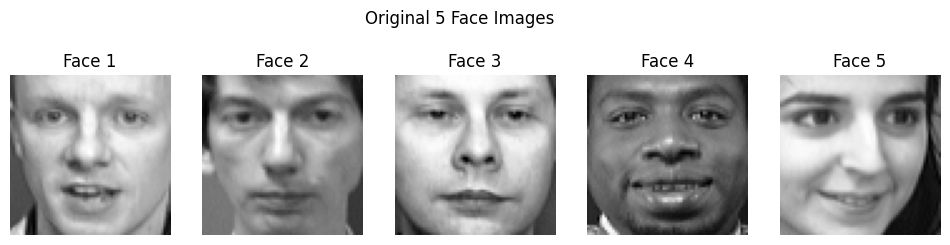

In [ ]:
plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_images[i], cmap='gray')
    plt.title(f"Face {i+1}")
    plt.axis('off')

plt.suptitle("Original 5 Face Images")
plt.show()

In [ ]:
# Flatten images
X = X_images.reshape(5, -1)

print("Original image shape:", X_images.shape)
print("Flattened data shape:", X.shape)
print("Each image has", X.shape[1], "pixels")

Original image shape: (5, 64, 64)
Flattened data shape: (5, 4096)
Each image has 4096 pixels


In [ ]:
# Calculate mean face
mean_face = np.mean(X, axis=0)

# Center the data
X_centered = X - mean_face

print("Mean face calculated.")
print("Centered data shape:", X_centered.shape)

Mean face calculated.
Centered data shape: (5, 4096)


In [ ]:

# Covariance matrix
covariance_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", covariance_matrix.shape)

Covariance matrix shape: (4096, 4096)


In [ ]:
# Singular Value Decomposition
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Eigenvalues of covariance matrix
eigenvalues = (S ** 2) / (X_centered.shape[0] - 1)

# Eigenvectors
eigenvectors = Vt

print("Number of eigenvalues:", len(eigenvalues))
print("Eigenvectors shape:", eigenvectors.shape)

Number of eigenvalues: 5
Eigenvectors shape: (5, 4096)


In [ ]:
print("Top 3 Eigenvalues:")

for i in range(3):
    print(f"Eigenvalue {i+1}: {eigenvalues[i]:.6f}")

Top 3 Eigenvalues:
Eigenvalue 1: 39.245899
Eigenvalue 2: 31.483017
Eigenvalue 3: 9.879340


In [ ]:
total_variance = np.sum(eigenvalues)

explained_variance = eigenvalues / total_variance

print("Explained variance by top 3 components:")

for i in range(3):
    print(
        f"PC{i+1}: {explained_variance[i]*100:.2f}%"
    )

print(
    f"\nTotal variance captured by top 3: "
    f"{np.sum(explained_variance[:3])*100:.2f}%"
)

Explained variance by top 3 components:
PC1: 45.29%
PC2: 36.33%
PC3: 11.40%

Total variance captured by top 3: 93.01%


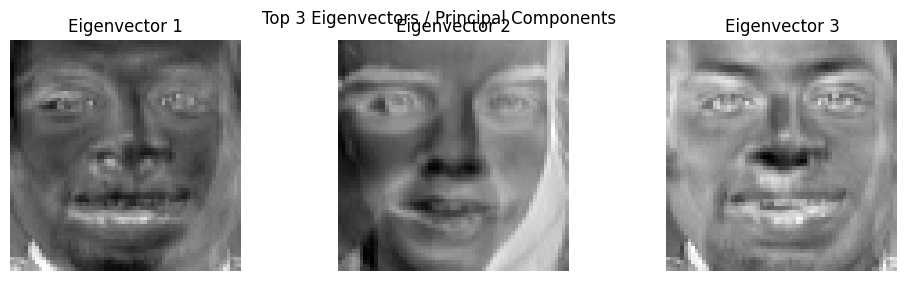

In [ ]:
plt.figure(figsize=(12, 3))

for i in range(3):
    eigenface = eigenvectors[i].reshape(64, 64)

    plt.subplot(1, 3, i + 1)
    plt.imshow(eigenface, cmap='gray')
    plt.title(f"Eigenvector {i+1}")
    plt.axis('off')

plt.suptitle("Top 3 Eigenvectors / Principal Components")
plt.show()

In [ ]:
# Select top 3 eigenvectors
top_3_eigenvectors = eigenvectors[:3]

# Convert original data into 3-dimensional PCA representation
compressed_data = X_centered @ top_3_eigenvectors.T

print("Original representation:", X.shape)
print("Compressed representation:", compressed_data.shape)

Original representation: (5, 4096)
Compressed representation: (5, 3)


In [ ]:
# Reconstruct images from 3 principal components
X_reconstructed = (
    compressed_data @ top_3_eigenvectors
) + mean_face

# Convert back to 64 x 64 images
reconstructed_images = X_reconstructed.reshape(5, 64, 64)

# Keep pixel values between 0 and 1
reconstructed_images = np.clip(reconstructed_images, 0, 1)

print("Reconstruction completed!")

Reconstruction completed!


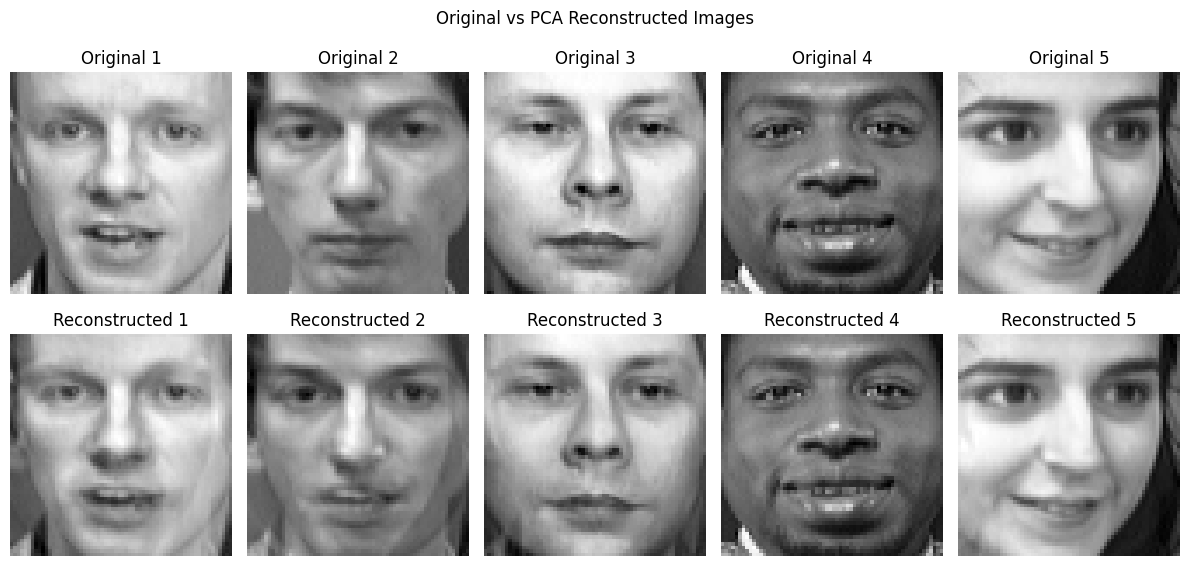

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(5):

    # Original
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_images[i], cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, 5, i + 6)
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title(f"Reconstructed {i+1}")
    plt.axis('off')

plt.suptitle("Original vs PCA Reconstructed Images")
plt.tight_layout()
plt.show()

In [ ]:
# Mean Squared Error
mse = np.mean((X_images - reconstructed_images) ** 2)

print(f"Mean Squared Error: {mse:.6f}")

Mean Squared Error: 0.001182


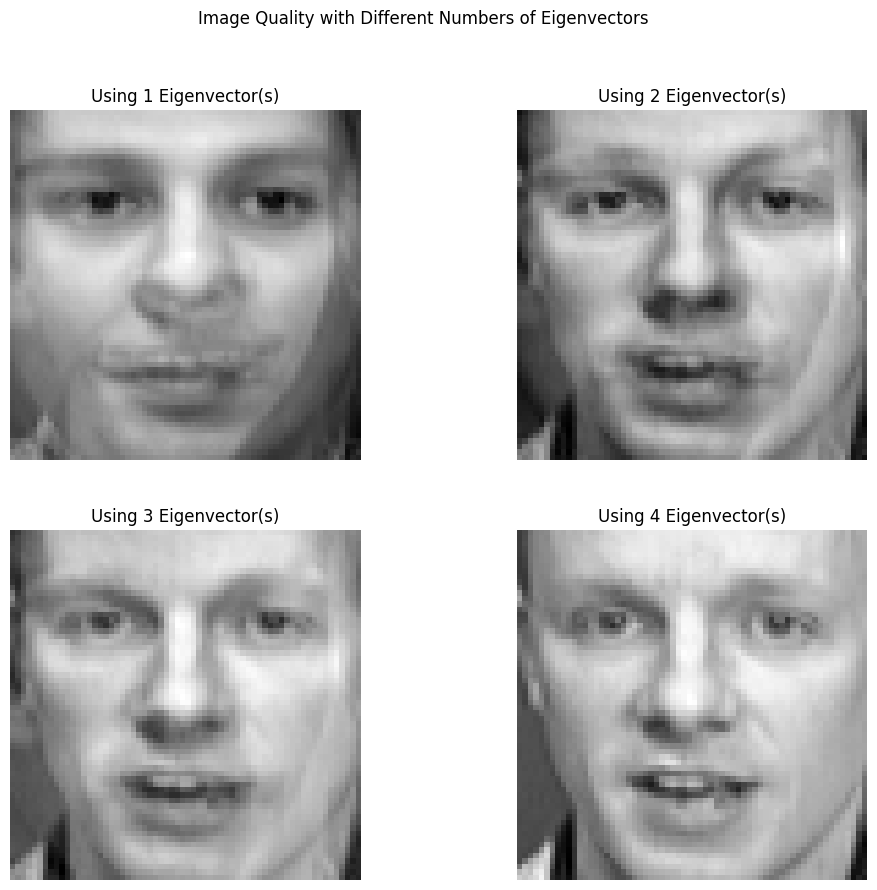

In [ ]:
components_list = [1, 2, 3, 4]

plt.figure(figsize=(12, 10))

for row, k in enumerate(components_list):

    # Select k components
    components = eigenvectors[:k]

    # Compress
    scores = X_centered @ components.T

    # Reconstruct
    reconstructed = scores @ components + mean_face

    # First face only
    reconstructed_face = reconstructed[0].reshape(64, 64)
    reconstructed_face = np.clip(reconstructed_face, 0, 1)

    plt.subplot(2, 2, row + 1)
    plt.imshow(reconstructed_face, cmap='gray')
    plt.title(f"Using {k} Eigenvector(s)")
    plt.axis('off')

plt.suptitle("Image Quality with Different Numbers of Eigenvectors")
plt.show()

In [ ]:
print("=" * 50)
print("IMAGE COMPRESSION VIA EIGENVALUES & EIGENVECTORS")
print("=" * 50)

print("Number of images        :", 5)
print("Original image size     : 64 x 64")
print("Pixels per image        :", 4096)
print("PCA components used     : 3")
print("Compressed dimensions   : 3")
print(
    "Variance captured       : "
    f"{np.sum(explained_variance[:3])*100:.2f}%"
)
print("Reconstruction MSE      :", f"{mse:.6f}")

print("\nConclusion:")
print("PCA reduces the dimensionality of the face images")
print("by representing them using the most important")
print("eigenvectors of the covariance matrix.")

IMAGE COMPRESSION VIA EIGENVALUES & EIGENVECTORS
Number of images        : 5
Original image size     : 64 x 64
Pixels per image        : 4096
PCA components used     : 3
Compressed dimensions   : 3
Variance captured       : 93.01%
Reconstruction MSE      : 0.001182

Conclusion:
PCA reduces the dimensionality of the face images
by representing them using the most important
eigenvectors of the covariance matrix.
